# Hamiltonian Flow Matching — Double-Well Potential (1D)

Transports a Gaussian source to a bimodal target in **1D** under the **double-well potential**
`V(x) = α x⁴/4 + β x²/2`.

The conditional path is a **Gaussian with BVP-solved parameters** `(μ(t), σ(t))`.
A dataset of OT-coupled pairs is pre-computed once; the BVP is solved for each pair via
`ParametricBVPGaussianPath.batch_solve`, then training samples from this cache.

**Workflow:**
1. Generate OT-coupled dataset `(x0, x1)`
2. `path.batch_solve(x0_dataset, x1_dataset)` — solve BVP for all pairs  
3. Train from cache (index-based sampling)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../../../'))

import torch
import numpy as np
import matplotlib.pyplot as plt
from torchdyn.core import NeuralODE

from torchcfm.hamiltonian import (
    DoubleWellPotential, ParametricBVPGaussianPath,
    flow_matching_loss, hamiltonian_energy, relative_hamiltonian_drift,
)
from torchcfm.optimal_transport import OTPlanSampler
from torchcfm.models.models_v2 import MLP
from torchcfm.utils import torch_wrapper

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)

dim        = 1
batch_size = 128
n_dataset  = 10_000   # number of pre-computed (x0, x1) pairs
n_iters    = 5500
lr         = 1e-3

alpha_dw = 0.15
beta_dw  = -3.0
sigma_bvp = 1e-4

print(f'device: {device}')

device: cuda


## Distributions

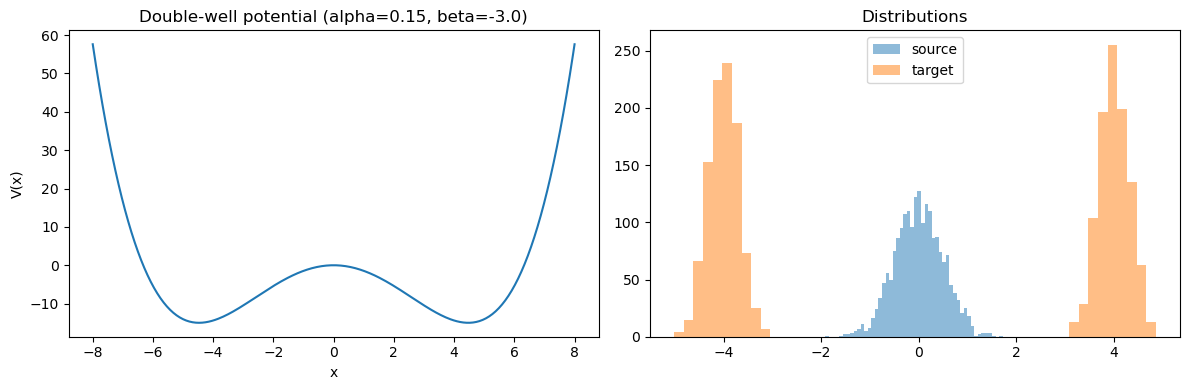

In [12]:
def sample_source(n):
    return torch.randn(n, 1) * 0.5

def sample_target(n, weights=(0.5, 0.5)):
    idx = torch.bernoulli(torch.full((n,), weights[1])).long()
    means = torch.tensor([-4.0, 4.0])
    return (means[idx] + torch.randn(n) * 0.3).unsqueeze(1)

x_range = torch.linspace(-8, 8, 300)
potential_vals = DoubleWellPotential(alpha_dw, beta_dw).energy(x_range.unsqueeze(1)).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x_range, potential_vals)
axes[0].set_xlabel('x'); axes[0].set_ylabel('V(x)')
axes[0].set_title(f'Double-well potential (alpha={alpha_dw}, beta={beta_dw})')

x0_vis = sample_source(2000); x1_vis = sample_target(2000)
axes[1].hist(x0_vis[:, 0].numpy(), bins=50, alpha=0.5, label='source')
axes[1].hist(x1_vis[:, 0].numpy(), bins=50, alpha=0.5, label='target')
axes[1].set_title('Distributions'); axes[1].legend()
plt.tight_layout(); plt.show()

## Potential, path — and pre-compute BVP dataset

Because the BVP solutions are indexed by exact `(x0, x1)` float keys, we must:
1. Apply OT coupling to the full dataset once.
2. Call `batch_solve` on those coupled pairs.
3. Sample indices (not new x0/x1 values) during training.

In [13]:
potential  = DoubleWellPotential(alpha=alpha_dw, beta=beta_dw)
path       = ParametricBVPGaussianPath(potential, sigma=sigma_bvp, n_steps=30, tol=1.0)
ot_sampler = OTPlanSampler(method='exact')

# Step 1: OT-couple the full dataset
x0_all = sample_source(n_dataset)
x1_all = sample_target(n_dataset)
x0_coupled, x1_coupled = ot_sampler.sample_plan(x0_all, x1_all)

print(f'Dataset: {n_dataset} OT-coupled (x0, x1) pairs. Solving BVPs...')

# Step 2: Pre-compute BVP for all pairs (may take a minute)
states = path.batch_solve(x0_coupled, x1_coupled)
print(f'Done. Trajectory tensor: {states.shape}  (pairs, time-steps, state-dim)')

/work2/Sebas/anaconda3/envs/Hamiltonian_Flows_Wass/lib/python3.10/site-packages/ot/lp/__init__.py:354: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)


Dataset: 10000 OT-coupled (x0, x1) pairs. Solving BVPs...
Done. Trajectory tensor: torch.Size([10000, 31, 4])  (pairs, time-steps, state-dim)


## Model and training

In [14]:
model     = MLP(dim + 1, out_dim=dim, w=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

x0_coupled = x0_coupled.to(device)
x1_coupled = x1_coupled.to(device)

model.train()
losses = []

for k in range(n_iters):
    optimizer.zero_grad()

    # Sample indices from the pre-computed cache
    idx = torch.randint(0, n_dataset, (batch_size,))
    x0_b = x0_coupled[idx]
    x1_b = x1_coupled[idx]

    t       = torch.rand((batch_size, 1), device=device)
    epsilon = torch.randn_like(x0_b)
    xt      = path.sample_xt(x0_b, x1_b, t, epsilon)
    ut      = path.compute_ut(x0_b, x1_b, t, xt)

    vt   = model(torch.cat([xt, t], dim=-1))
    loss = flow_matching_loss(vt, ut)

    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if k % 1000 == 0 or k == n_iters - 1:
        print(f'step {k:5d}: loss = {loss.item():.5f}')

step     0: loss = 12.88595
step  1000: loss = 0.03790
step  2000: loss = 0.01608
step  3000: loss = 0.01440
step  4000: loss = 0.01527
step  5000: loss = 0.04325
step  5499: loss = 0.03151


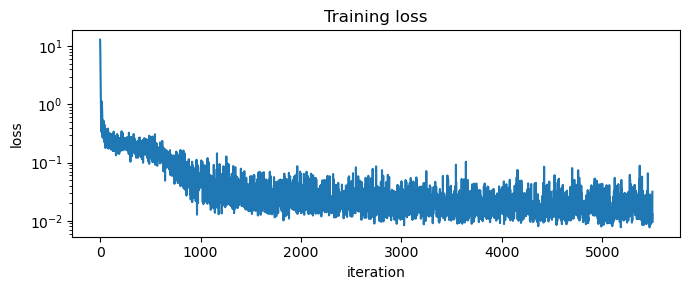

In [15]:
plt.figure(figsize=(7, 3))
plt.semilogy(losses)
plt.xlabel('iteration'); plt.ylabel('loss'); plt.title('Training loss')
plt.tight_layout(); plt.show()

## Evaluation

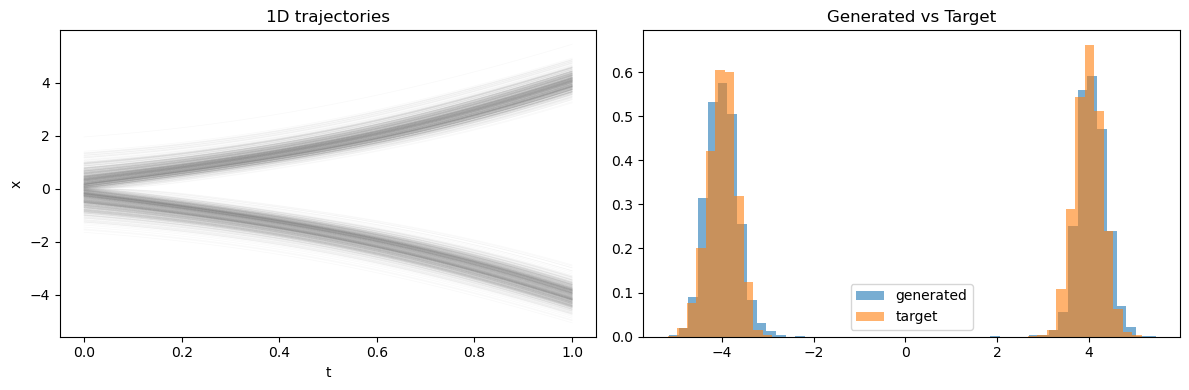

In [16]:
model.eval()
node = NeuralODE(torch_wrapper(model), sensitivity='adjoint', solver='euler')

with torch.no_grad():
    traj = node.trajectory(
        sample_source(5000).to(device),
        t_span=torch.linspace(0, 1, 100, device=device),
    )

traj   = traj.cpu()
x1_ref = sample_target(5000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in range(0, 5000, 5):
    axes[0].plot(torch.linspace(0, 1, 100), traj[:, i, 0], alpha=0.05, c='gray', linewidth=0.5)
axes[0].set_xlabel('t'); axes[0].set_ylabel('x')
axes[0].set_title('1D trajectories')

axes[1].hist(traj[-1, :, 0].numpy(), bins=50, alpha=0.6, label='generated', density=True)
axes[1].hist(x1_ref[:, 0].numpy(), bins=50, alpha=0.6, label='target', density=True)
axes[1].set_title('Generated vs Target'); axes[1].legend()
plt.tight_layout(); plt.show()

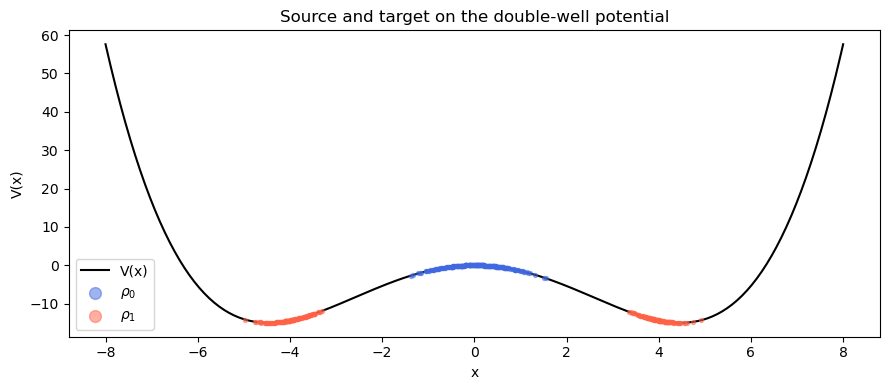

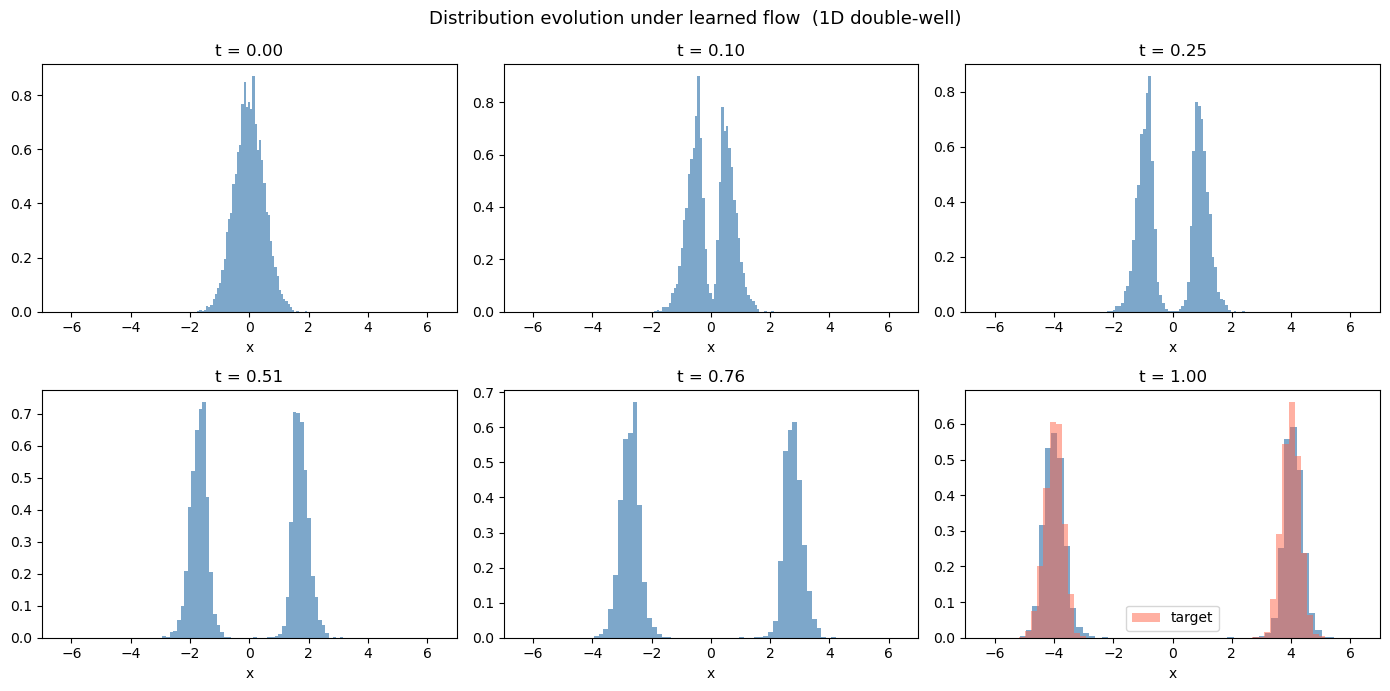

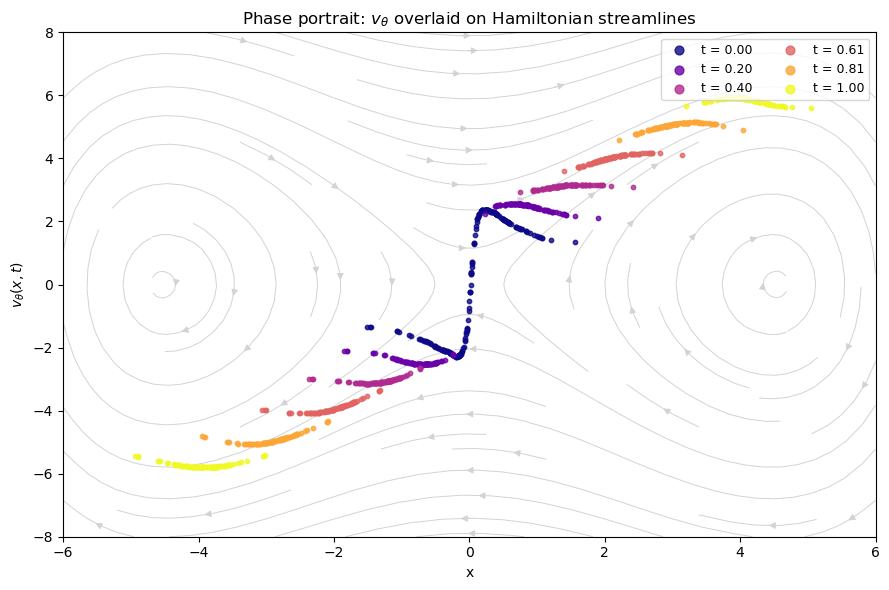

In [17]:
# Source and target samples plotted ON the potential curve
x_curve = torch.linspace(-8, 8, 300)
V_curve  = potential.energy(x_curve.unsqueeze(1)).numpy()
x0_pts   = sample_source(300)
x1_pts   = sample_target(300)

plt.figure(figsize=(9, 4))
plt.plot(x_curve.numpy(), V_curve, 'k-', linewidth=1.5, zorder=2, label='V(x)')
plt.scatter(x0_pts[:, 0].numpy(), potential.energy(x0_pts).numpy(),
            s=8, alpha=0.5, c='royalblue', label=r'$\rho_0$', zorder=3)
plt.scatter(x1_pts[:, 0].numpy(), potential.energy(x1_pts).numpy(),
            s=8, alpha=0.5, c='tomato', label=r'$\rho_1$', zorder=3)
plt.xlabel('x'); plt.ylabel('V(x)'); plt.legend(markerscale=3)
plt.title('Source and target on the double-well potential')
plt.tight_layout(); plt.show()

# Distribution evolution — histograms at six time steps
t_snaps = [0, 10, 25, 50, 75, 99]
snap_labels = [f't = {i / 99:.2f}' for i in t_snaps]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, ti, lbl in zip(axes.ravel(), t_snaps, snap_labels):
    ax.hist(traj[ti, :, 0].numpy(), bins=50, density=True, alpha=0.7, color='steelblue')
    ax.set_xlim(-7, 7); ax.set_title(lbl); ax.set_xlabel('x')
fig.axes[-1].hist(x1_ref[:, 0].numpy(), bins=50, density=True,
                  alpha=0.5, color='tomato', label='target')
fig.axes[-1].legend()
plt.suptitle('Distribution evolution under learned flow  (1D double-well)', fontsize=13)
plt.tight_layout(); plt.show()

# Phase portrait: (x, v_θ(x, t)) at multiple time steps
# Background streamlines show the Hamiltonian dynamics  x' = v,  v' = -V'(x)
t_span_ph = torch.linspace(0, 1, 100)
with torch.no_grad():
    traj_ph = node.trajectory(sample_source(200).to(device), t_span=t_span_ph.to(device))
traj_ph = traj_ph.cpu()

t_idx  = [0, 20, 40, 60, 80, 99]
colors = plt.cm.plasma(np.linspace(0, 1, len(t_idx)))

fig, ax = plt.subplots(figsize=(9, 6))
for ti, c in zip(t_idx, colors):
    xt = traj_ph[ti]
    t_val = t_span_ph[ti]
    with torch.no_grad():
        vt_ph = model(torch.cat([xt.to(device),
                                  t_val.expand(xt.shape[0], 1).to(device)], dim=-1)).cpu()
    ax.scatter(xt[:, 0].numpy(), vt_ph[:, 0].numpy(),
               s=10, alpha=0.8, color=c, label=f't = {t_val:.2f}', zorder=3)

# Hamiltonian streamlines
x_bg = np.linspace(-6, 6, 30)
v_bg = np.linspace(-8, 8, 30)
Xg, Vg = np.meshgrid(x_bg, v_bg)
dV_dx = alpha_dw * Xg**3 + beta_dw * Xg
speed = np.sqrt(Vg**2 + dV_dx**2) + 1e-8
ax.streamplot(x_bg, v_bg, Vg / speed, -dV_dx / speed,
              color='lightgray', density=0.8, linewidth=0.7, zorder=1)

ax.set_xlabel('x'); ax.set_ylabel(r'$v_\theta(x, t)$')
ax.set_title(r'Phase portrait: $v_\theta$ overlaid on Hamiltonian streamlines')
ax.legend(markerscale=2, loc='upper right', fontsize=9, ncol=2)
plt.tight_layout(); plt.show()

## Hamiltonian conservation

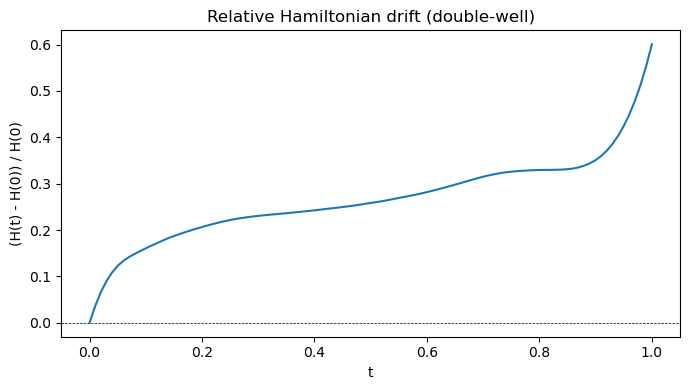

Max |drift|: 0.6006


In [18]:
t_span   = torch.linspace(0, 1, 100, device=device)
x0_eval  = sample_source(500).to(device)

with torch.no_grad():
    traj_eval = node.trajectory(x0_eval, t_span=t_span)

H     = hamiltonian_energy(model, potential, traj_eval, t_span)
drift = relative_hamiltonian_drift(H)

plt.figure(figsize=(7, 4))
plt.plot(t_span.cpu().numpy(), drift)
plt.axhline(0, color='k', linewidth=0.5, linestyle='--')
plt.xlabel('t'); plt.ylabel('(H(t) - H(0)) / H(0)')
plt.title('Relative Hamiltonian drift (double-well)')
plt.tight_layout(); plt.show()
print(f'Max |drift|: {np.abs(drift).max():.4f}')